### Подготовка данных

In [1]:
import warnings
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-mean-temp.csv"
time_series = pd.read_csv(url)

time_series.sample(5)

,Month,Temperature
197,1936-06,58.6
95,1927-12,35.2
110,1929-03,41.0
23,1921-12,42.8
141,1931-10,46.6


In [2]:
len(time_series)

240

In [3]:
time_series.isnull().sum()

,0
Month,0
Temperature,0


In [4]:
time_series.dtypes

,0
Month,object
Temperature,float64


In [5]:
time_series['Month'] = pd.to_datetime(time_series['Month'])
time_series.set_index('Month', inplace=True)

In [6]:
time_series.dtypes

,0
Temperature,float64


In [7]:
time_series.sample(5)

,Temperature
Month,
1934-12-01,45.8
1932-07-01,62.1
1925-03-01,40.8
1938-09-01,57.0
1929-09-01,59.8


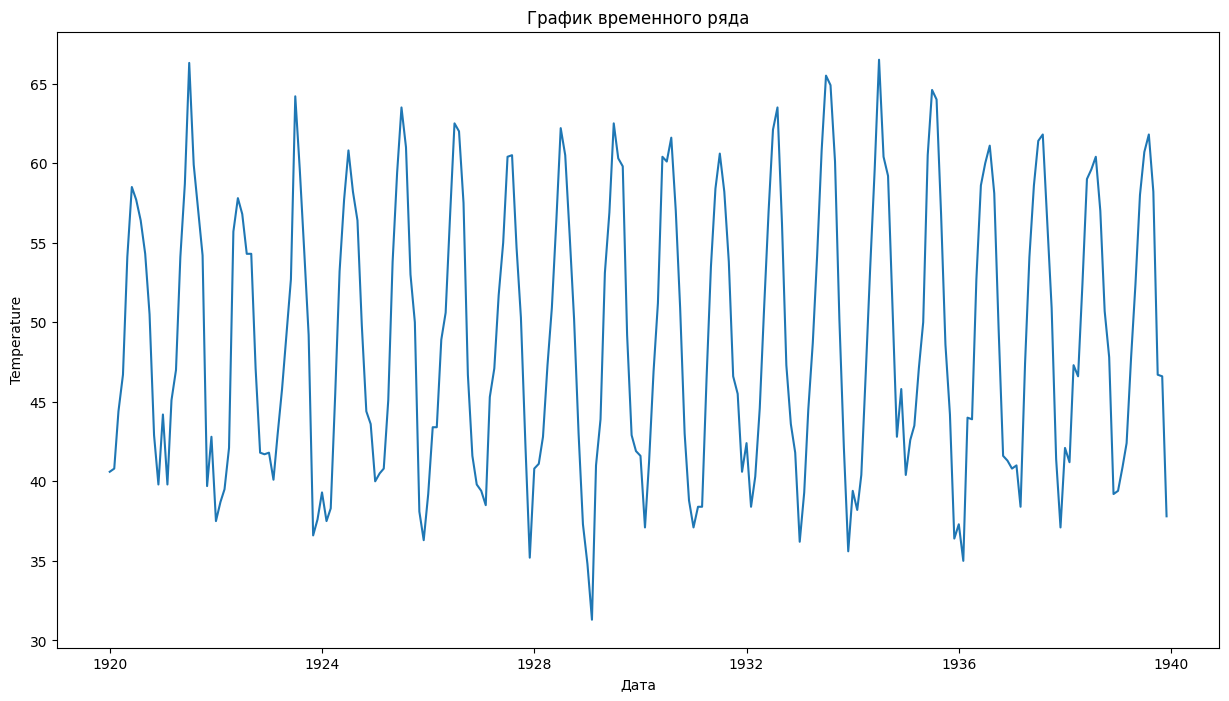

In [8]:
plt.figure(figsize=(15,8))
plt.plot(time_series['Temperature'])
plt.title('График временного ряда')
plt.xlabel('Дата')
plt.ylabel('Temperature')
plt.show()

In [9]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore")

In [10]:
train, test = train_test_split(time_series, test_size=0.2, shuffle=False)

In [11]:
train.shape

(192, 1)

In [12]:
test.shape

(48, 1)

In [13]:
test.head()

,Temperature
Month,
1936-01-01,37.3
1936-02-01,35.0
1936-03-01,44.0
1936-04-01,43.9
1936-05-01,52.7


### Поиск параметров

In [14]:
def search_optimal_arima(time_series, seasonal_cycle):
    # Взял максимальный интервал, которое мое устройство осилило
    order_vals = diff_vals = ma_vals = range(0, 10)
    pdq_combinations = list(itertools.product(order_vals, diff_vals, ma_vals))

    smallest_aic = float("inf")
    optimal_order_param = None

    for order_param in pdq_combinations:
        try:
            arima_model = ARIMA(time_series,
                                order=order_param,
                                enforce_stationarity=False,
                                enforce_invertibility=False)

            model_results = arima_model.fit()
            if model_results.aic < smallest_aic:
                smallest_aic = model_results.aic
                optimal_order_param = order_param
        except:
            print("Aaa")
            continue

    return optimal_order_param, smallest_aic

seasonal_cycle_length = 12
#optimal_order_param, smallest_aic = search_optimal_arima(train, seasonal_cycle_length)
optimal_order_param, smallest_aic = (9, 0, 9), 852.8862766296019
print('ARIMA{} - AIC:{}'.format(optimal_order_param, smallest_aic))

ARIMA(9, 0, 9) - AIC:852.8862766296019


### Обучение модели

In [15]:
from statsmodels.tsa.arima.model import ARIMA

order = optimal_order_param

model = ARIMA(train, order=order)

In [16]:
fitted_model = model.fit()
fitted_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:            Temperature   No. Observations:                  192
Model:                 ARIMA(9, 0, 9)   Log Likelihood                -448.918
Date:                Tue, 28 Apr 2026   AIC                            937.836
Time:                        15:25:35   BIC                           1002.986
Sample:                    01-01-1920   HQIC                           964.222
                         - 12-01-1935                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         48.8389      0.286    170.715      0.000      48.278      49.400
ar.L1         -1.4284      0.320     -4.464      0.000      -2.056      -0.801
ar.L2         -0.6711      0.479     -1.400      0.161      -1.610       0.268
ar.L3          0.3781      0.288      1.311      0.190      -0.187       0.943
ar.L4          0.5566      0.142      3.933      0.000       0.279       0.834
ar.L5         -0.3931      0.153     -2.563      0.010      -0.694      -0.092
ar.L6         -1.3051      0.163     -7.999      0.000      -1.625      -0.985
ar.L7         -1.2221      0.400     -3.056      0.002      -2.006      -0.438
ar.L8         -0.2829      0.420     -0.673      0.501      -1.106       0.541
ar.L9          0.2119      0.202      1.051      0.293      -0.183       0.607
ma.L1          1.8417      0.428      4.298      0.000       1.002       2.681
ma.L2          1.4007      0.879      1.594      0.111      -0.322       3.123
ma.L3          0.1009      0.802      0.126      0.900      -1.470       1.672
ma.L4         -0.6848      0.276     -2.484      0.013      -1.225      -0.145
ma.L5         -0.0747      0.539     -0.138      0.890      -1.132       0.982
ma.L6          1.2515      0.861      1.454      0.146      -0.436       2.939
ma.L7          1.8397      0.761      2.419      0.016       0.349       3.330
ma.L8          1.0617      0.560      1.895      0.058      -0.037       2.160
ma.L9          0.1924      0.241      0.798      0.425      -0.280       0.665
sigma2         5.7692      1.443      3.999      0.000       2.942       8.597
===================================================================================
Ljung-Box (L1) (Q):                   0.48   Jarque-Bera (JB):                 1.27
Prob(Q):                              0.49   Prob(JB):                         0.53
Heteroskedasticity (H):               0.62   Skew:                             0.12
Prob(H) (two-sided):                  0.05   Kurtosis:                         3.32
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

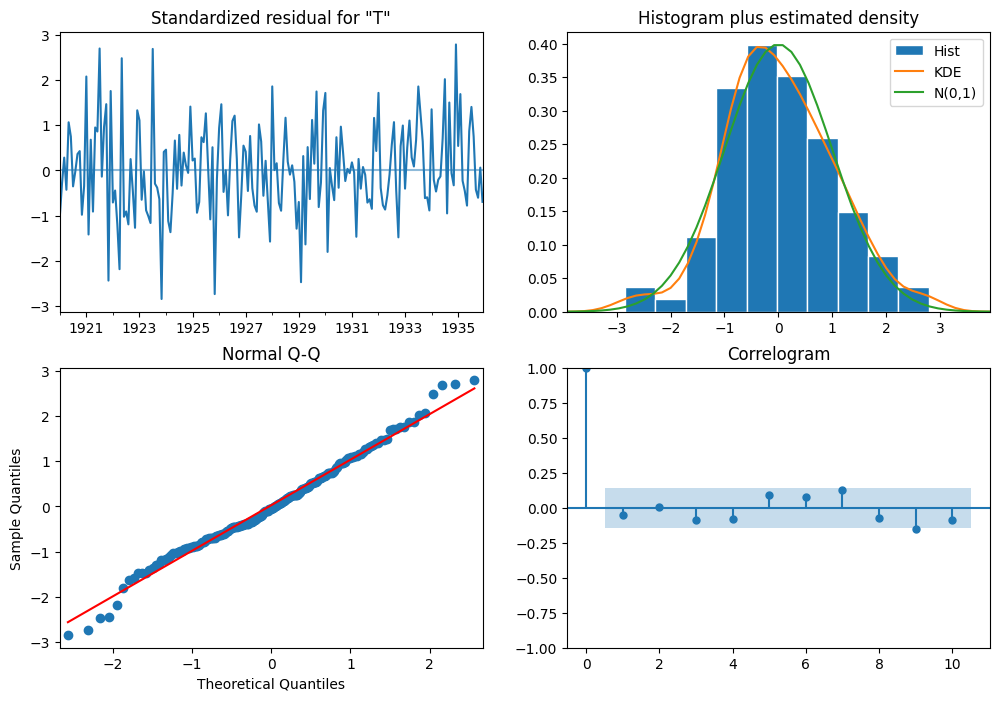

In [17]:
fitted_model.plot_diagnostics(figsize=(12, 8))
plt.show()

### Прогноз

In [18]:
pred = fitted_model.get_prediction(start=test.index[0], end=test.index[-1], dynamic=False)
forecast_values = pred.predicted_mean

In [19]:
actual_values = test
forecast_mse = ((forecast_values - actual_values) ** 2).mean()

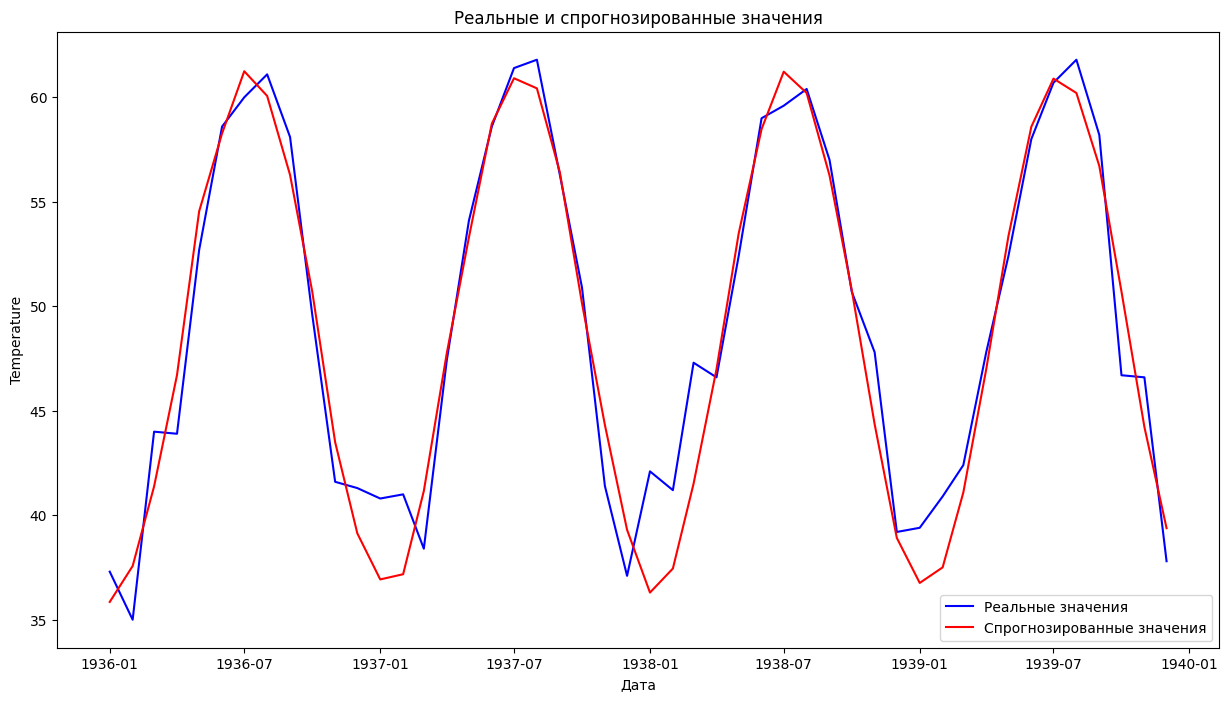

In [20]:
plt.figure(figsize=(15,8))

plt.plot(actual_values.index, actual_values, label='Реальные значения', color='blue')

plt.plot(forecast_values.index, forecast_values, label='Спрогнозированные значения', color='red')

plt.title('Реальные и cпрогнозированные значения')
plt.xlabel('Дата')
plt.ylabel('Temperature')
plt.legend()

plt.show()

### Реализации бутстрапа

In [21]:
def residual_bootstrap(fitted_model, steps, n_bootstrap=1000):
    residuals = fitted_model.resid.values
    forecasts = []

    for _ in range(n_bootstrap):
        boot_resid = np.random.choice(residuals, size=steps, replace=True)
        # Симуляция будущих значений с учётом структуры модели
        sim = fitted_model.simulate(
            nsimulations=steps,
            anchor='end',          # начать с конца обучающей выборки
            repetitions=1,
            random_errors=boot_resid.reshape(-1,1)  # передаём бутстреп-остатки
        )

        sim_values = np.asarray(sim).flatten()
        # Если нужно добавить внешний тренд/сезонность – убедитесь, что модель их не содержит
        # В противном случае не применяйте add_trend_and_seasonal повторно.
        boot_forecast = sim_values
        forecasts.append(boot_forecast)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)
    return lower, upper, forecasts

In [22]:
# max - половина максимальной ошибки
# mean - половина средней ошибки
# median - половина медианной ошибки
def naive_bootstraps(fitted_model, steps, method, n_bootstrap=1000):
    residuals = fitted_model.resid.values
    abs_resids = np.abs(residuals)

    if method == 'max':
        error_magnitude = np.max(abs_resids) / 2.0
    elif method == 'mean':
        error_magnitude = np.mean(abs_resids) / 2.0
    elif method == 'median':
        error_magnitude = np.median(abs_resids) / 2.0
    else:
        raise ValueError("[naive] no such method ")

    forecasts = []

    for _ in range(n_bootstrap):
        boot_resid = error_magnitude
        # Симуляция будущих значений с учётом структуры модели
        sim = fitted_model.simulate(
            nsimulations=steps,
            anchor='end',          # начать с конца обучающей выборки
            repetitions=1,
            random_errors=boot_resid.reshape(-1,1)  # передаём бутстреп-остатки
        )

        sim_values = np.asarray(sim).flatten()
        # Если нужно добавить внешний тренд/сезонность – убедитесь, что модель их не содержит
        # В противном случае не применяйте add_trend_and_seasonal повторно.
        boot_forecast = sim_values
        forecasts.append(boot_forecast)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)
    return lower, upper, forecasts

In [23]:
!pip install arch

import arch
from arch.bootstrap import MovingBlockBootstrap

def arch_block_bootstrap(fitted_model, steps, block_length=12, n_bootstrap=1000):
    residuals = fitted_model.resid.values
    point_forecast = fitted_model.forecast(steps=steps)

    mbb = MovingBlockBootstrap(block_length, residuals)
    forecasts = []

    for data in mbb.bootstrap(n_bootstrap):
        # data[0][0] содержит сгенерированный ряд остатков
        boot_resid = data[0][0]

        if len(boot_resid) >= steps:
            boot_forecast = point_forecast.values + boot_resid[:steps]
            forecasts.append(boot_forecast)
        else:
            # Если остатков не хватает, повторяем их циклически
            repeated_resid = np.tile(boot_resid, int(np.ceil(steps / len(boot_resid))))[:steps]
            boot_forecast = point_forecast.values + repeated_resid
            forecasts.append(boot_forecast)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)

    return lower, upper, forecasts

In [24]:
!pip install tsbootstrap

from tsbootstrap import WholeSieveBootstrap

def sieve_bootstrap(fitted_model, steps, min_lag=1, max_lag=12, n_bootstrap=1000, random_state=42):
    residuals = fitted_model.resid.values

    centered_resid = residuals - np.mean(residuals)

    sieve = WholeSieveBootstrap(n_bootstraps=n_bootstrap)

    boot_residuals = sieve.bootstrap(centered_resid)

    boot_residuals_list = []
    for _ in range(n_bootstrap):
        boot_residuals_list.append(next(boot_residuals))
    boot_residuals = np.array(boot_residuals_list)

    forecasts = []
    for i in range(n_bootstrap):
        boot_resid = boot_residuals[i, :]
        sim = fitted_model.simulate(
            nsimulations=steps,
            anchor='end',
            repetitions=1,
            random_errors=boot_resid.reshape(-1, 1)
        )
        sim_values = np.asarray(sim).flatten()
        forecasts.append(sim_values)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)
    return lower, upper, forecasts

In [25]:
from tsbootstrap import MovingBlockBootstrap as tsbootstrap_mbb

def tsbootstrap_block_bootstrap(fitted_model, steps, block_length=12, n_bootstrap=1000, random_state=42):
    residuals = fitted_model.resid.values

    centered_resid = residuals - np.mean(residuals)

    mbb = tsbootstrap_mbb(n_bootstraps=n_bootstrap, rng=random_state, block_length=block_length)

    boot_residuals = mbb.bootstrap(centered_resid)

    boot_residuals_list = []
    for _ in range(n_bootstrap):
        boot_residuals_list.append(next(boot_residuals))
    boot_residuals = np.array(boot_residuals_list)

    forecasts = []
    for i in range(n_bootstrap):
        boot_resid = boot_residuals[i, :]
        sim = fitted_model.simulate(
            nsimulations=steps,
            anchor='end',
            repetitions=1,
            random_errors=boot_resid.reshape(-1, 1)
        )
        sim_values = np.asarray(sim).flatten()
        forecasts.append(sim_values)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)
    return lower, upper, forecasts

### Сравнение методов

In [26]:
def evaluate(true_values, lower, upper):
    true_vals = np.array(true_values).flatten()

    # доля истинных значений, попавших в интервал
    coverage = np.mean((lower <= true_vals[:len(lower)]) & (true_vals[:len(lower)] <= upper))

    # средняя ширина интервала
    avg_width = np.mean(upper - lower)
    return coverage, avg_width

forecast_steps = 24
forecast = fitted_model.forecast(steps=forecast_steps)

test_values = test.values.flatten()[:forecast_steps]

results = {}

# ARIMA
try:
    prediction = fitted_model.get_forecast(forecast_steps)
    arima_forecast = prediction.predicted_mean
    arima_ci = prediction.conf_int(alpha=0.05)
    lower_arima = arima_ci.iloc[:, 0]
    upper_arima = arima_ci.iloc[:, 1]
    coverage_arima, width_arima = evaluate(test_values, lower_arima, upper_arima)
    results['ARIMA'] = {'coverage': coverage_arima, 'width': width_arima, 'lower': lower_arima, 'upper': upper_arima}
    print("ARIMA - OK")
except Exception as e:
    print(f"Arima error: {e}")

# Residual Bootstrap
try:
    lower_res_c, upper_res_c, all_forecasts_res_c  = residual_bootstrap(fitted_model, forecast_steps)
    coverage_res_c, width_res_c = evaluate(test_values, lower_res_c, upper_res_c)
    results['Residual Bootstrap Correct'] = {'coverage': coverage_res_c, 'width': width_res_c, 'lower': lower_res_c, 'upper': upper_res_c}
    print("Residual Bootstrap Correct - OK")
except Exception as e:
    print(f"Residual Bootstrap Correct error: {e}")

# Naive
try:
    for method in ["max", "mean", "median"]:
        lower_naive, upper_naive, all_forecasts_naive  = naive_bootstraps(fitted_model, forecast_steps, method)
        coverage_naive, width_naive = evaluate(test_values, lower_naive, upper_naive)
        results['Naive-' + method] = {'coverage': coverage_naive, 'width': width_naive, 'lower': lower_naive, 'upper': upper_naive}
        print(f" ### Naive {method} - OK")
    print("Naive - OK")
except Exception as e:
    print(f"Naive: {e}")

# ARCH block Bootstrap
try:
    lower_arch, upper_arch, _ = arch_block_bootstrap(fitted_model, forecast_steps, block_length=12)
    coverage_arch, width_arch = evaluate(test_values, lower_arch, upper_arch)
    results['ARCH Block Bootstrap'] = {'coverage': coverage_arch, 'width': width_arch, 'lower': lower_arch, 'upper': upper_arch}
    print("ARCH Block Bootstrap - OK")
except Exception as e:
    print(f"ARCH Block Bootstrap error: {e}")

# Sieve bootstrap
try:
    lower_sieve, upper_sieve, _ = sieve_bootstrap(fitted_model, forecast_steps)
    coverage_sieve, width_sieve = evaluate(test_values, lower_sieve, upper_sieve)
    results['Sieve Bootstrap'] = {'coverage': coverage_sieve, 'width': width_sieve, 'lower': lower_sieve, 'upper': upper_sieve}
    print("Sieve Bootstrap - OK")
except Exception as e:
    print(f"Sieve Bootstrap error: {e}")

# tsbootstrap block bootstrap
try:
    lower_block, upper_block, _ = tsbootstrap_block_bootstrap(fitted_model, forecast_steps)
    coverage_block, width_block = evaluate(test_values, lower_block, upper_block)
    results['Tsbootstrap Block Bootstrap'] = {'coverage': coverage_block, 'width': width_block, 'lower': lower_block, 'upper': upper_block}
    print("Tsbootstrap Block Bootstrap - OK")
except Exception as e:
    print(f"Tsbootstrap Block Bootstrap error: {e}")

results_df = pd.DataFrame(results).T[['coverage', 'width']]
print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ:")
print("="*50)
print(results_df)

ARIMA - OK
Residual Bootstrap Correct - OK
 ### Naive max - OK
 ### Naive mean - OK
 ### Naive median - OK
Naive - OK
ARCH Block Bootstrap - OK
[-8.2718636  -1.39002318  1.03834042 -1.42766591  3.13627361  2.07998833
 -1.01131806 -0.10948919  0.95958126  1.12527372 -2.67346928 -0.93358708
  5.41153222 -3.68758058  1.72148426 -2.37610529  2.40972514  2.1720832
  6.80161834 -0.37941222  2.40016086  3.67088034 -6.18519501  4.39528839
 -1.80624865 -1.14323566 -3.00737611 -5.49152368  6.16664536 -2.58593183
 -2.28745208 -2.99472413  0.59035467 -1.14559546 -3.17997079  3.25836103
  2.70995538 -1.6352725  -0.08264037 -2.20799955 -2.52465254 -2.89816586
  6.59190945 -0.75277705 -0.96682239 -1.59372804 -7.02185114  0.97319702
  1.09530515 -2.77835375 -3.38021539 -1.2639146   1.59029329 -1.02885672
  1.89347406 -0.85155881  0.93319956  0.24371273 -0.16344573  3.42112678
  0.50505522  0.60918042 -2.31731482 -1.7388328   1.75927974  1.49487609
  3.04843544  0.13854045 -2.67050718  1.21710955 -6.69

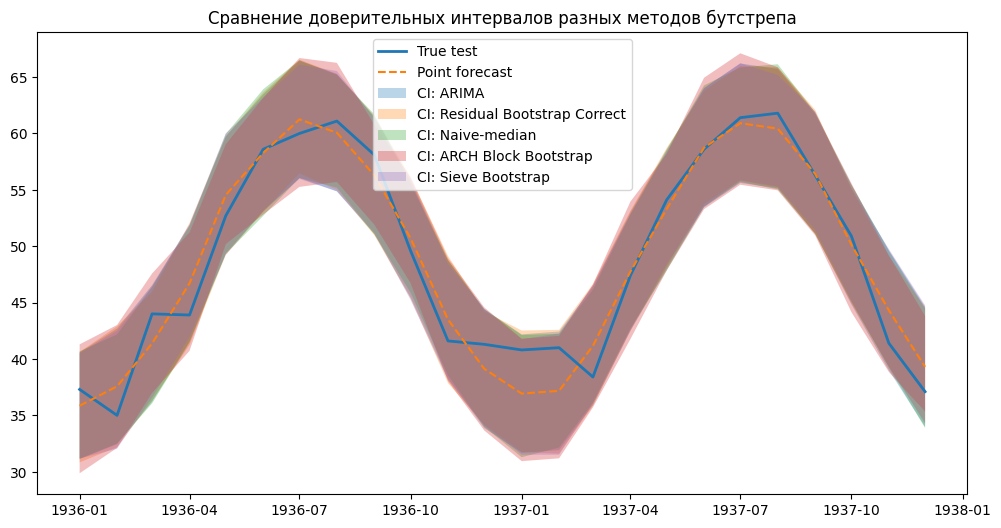

In [27]:
plt.figure(figsize=(12,6))
plt.plot(test.index[:forecast_steps], test_values, label='True test', linewidth=2)
plt.plot(test.index[:forecast_steps], forecast[:forecast_steps], label='Point forecast', linestyle='--')

to_plot = ['ARIMA', 'Residual Bootstrap Correct', 'Naive-median', 'ARCH Block Bootstrap', 'Sieve Bootstrap']

for name in results.keys():
    if name not in to_plot:
        continue

    lower = results[name]['lower']
    upper = results[name]['upper']

    plt.fill_between(test.index[:forecast_steps], lower, upper, alpha=0.3, label=f'CI: {name}')

plt.legend()
plt.title('Сравнение доверительных интервалов разных методов бутстрепа')
plt.show()